Task 1: Identify prediction target
Task 2: Data loading and exploration
Task 3: Data splitting
Task 4: Missing value handling
Task 5: Encoding categorical variables
Task 6: Feature scaling
Task 7: Feature selection
Task 8: Address class imbalance
Task 9: Train logistic regression model

## 1. Identifying the Prediction Target

The objective of the marketing campaign is to determine whether a contacted client subscribes to a term deposit. Therefore, the appropriate prediction target is the variable **`y`**, which indicates whether the client subscribed to the product.

The variable `y` takes two possible values: **"yes"** and **"no"**, making this a **binary classification problem**. The goal of the machine learning model is to predict this outcome using the available information.

This variable directly reflects the business objective of the marketing campaign, which is to identify clients who are likely to subscribe to a term deposit so that the bank can target its marketing efforts more effectively.

In [54]:
# Load the dataset
import pandas as pd

df = pd.read_csv("bank-additional.csv", sep=";")

# Inspect columns
df.columns

Index(['age', 'job', 'marital', 'education', 'default', 'housing', 'loan',
       'contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'emp.var.rate', 'cons.price.idx',
       'cons.conf.idx', 'euribor3m', 'nr.employed', 'y'],
      dtype='object')

In [55]:
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,30,blue-collar,married,basic.9y,no,yes,no,cellular,may,fri,...,2,999,0,nonexistent,-1.8,92.893,-46.2,1.313,5099.1,no
1,39,services,single,high.school,no,no,no,telephone,may,fri,...,4,999,0,nonexistent,1.1,93.994,-36.4,4.855,5191.0,no
2,25,services,married,high.school,no,yes,no,telephone,jun,wed,...,1,999,0,nonexistent,1.4,94.465,-41.8,4.962,5228.1,no
3,38,services,married,basic.9y,no,unknown,unknown,telephone,jun,fri,...,3,999,0,nonexistent,1.4,94.465,-41.8,4.959,5228.1,no
4,47,admin.,married,university.degree,no,yes,no,cellular,nov,mon,...,1,999,0,nonexistent,-0.1,93.200,-42.0,4.191,5195.8,no


In [56]:
df["y"].value_counts()

y
no     3668
yes     451
Name: count, dtype: int64

In [57]:
df["y"].value_counts(normalize=True)

y
no     0.890507
yes    0.109493
Name: proportion, dtype: float64

Some variables in the dataset may superficially appear to be possible targets, but they do not correspond to the objective of the marketing campaign.

For example:

**duration**  
This variable represents the length of the phone call. While it is often highly predictive of the subscription outcome, it is only known after the call has finished. Because the prediction should be made at the time of contact, using this variable would introduce data leakage and produce unrealistically optimistic model performance.

**campaign**  
This variable records the number of contacts performed during the campaign for a given client. Although it describes campaign activity, it is not the outcome of interest. The goal is not to predict how many contacts will occur, but whether the client subscribes to the term deposit.

For these reasons, the variable `y` remains the correct prediction target for this assignment.

## 2. Data Loading and Exploration

Before performing any preprocessing or modeling, it is necessary to explore the dataset to understand its structure and characteristics.

This includes inspecting the number of observations, the number of features, the data types of variables, and the distribution of the target variable. In addition, we identify which variables are numerical and which are categorical, and we examine whether the dataset contains explicit or implicit missing values.

In [58]:
print("Dataset shape:", df.shape)
print("\nColumn names:")
print(df.columns)

print("\nData types:")
print(df.dtypes)

Dataset shape: (4119, 21)

Column names:
Index(['age', 'job', 'marital', 'education', 'default', 'housing', 'loan',
       'contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'emp.var.rate', 'cons.price.idx',
       'cons.conf.idx', 'euribor3m', 'nr.employed', 'y'],
      dtype='object')

Data types:
age                 int64
job                object
marital            object
education          object
default            object
housing            object
loan               object
contact            object
month              object
day_of_week        object
duration            int64
campaign            int64
pdays               int64
previous            int64
poutcome           object
emp.var.rate      float64
cons.price.idx    float64
cons.conf.idx     float64
euribor3m         float64
nr.employed       float64
y                  object
dtype: object


In [59]:
numerical_cols = df.select_dtypes(include=["int64", "float64"]).columns
categorical_cols = df.select_dtypes(include=["object"]).columns

print("Numerical variables:")
print(numerical_cols)

print("\nCategorical variables:")
print(categorical_cols)

Numerical variables:
Index(['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate',
       'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed'],
      dtype='object')

Categorical variables:
Index(['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
       'month', 'day_of_week', 'poutcome', 'y'],
      dtype='object')


The dataset contains both numerical and categorical variables. Numerical variables include demographic and macroeconomic indicators such as age, euribor3m, and cons.price.idx. Categorical variables include attributes such as job type, marital status, education level, and contact method.

Categorical variables will later require encoding before they can be used by a machine learning model.

In [60]:
df["y"].value_counts()

y
no     3668
yes     451
Name: count, dtype: int64

In [61]:
df["y"].value_counts(normalize=True)

y
no     0.890507
yes    0.109493
Name: proportion, dtype: float64

The distribution of the target variable shows that the dataset is imbalanced, with a much larger proportion of "no" responses than "yes" responses. This imbalance may affect model training and evaluation and will be addressed later when discussing class imbalance handling.

In [62]:
df.isna().sum()

age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64

The dataset does not contain explicit missing values represented as NaN. However, several categorical variables include the category "unknown", which may represent implicit missing information. These implicit missing values will need to be considered during preprocessing.

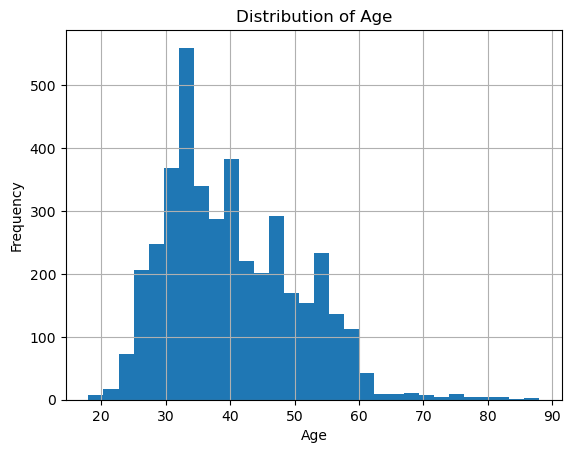

In [63]:
import matplotlib.pyplot as plt

df["age"].hist(bins=30)
plt.title("Distribution of Age")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

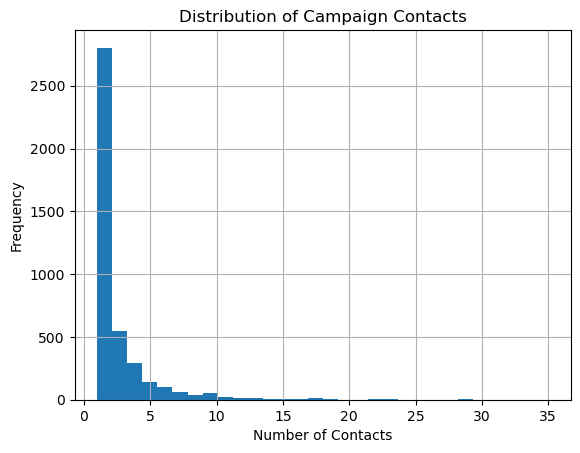

In [64]:
df["campaign"].hist(bins=30)
plt.title("Distribution of Campaign Contacts")
plt.xlabel("Number of Contacts")
plt.ylabel("Frequency")
plt.show()

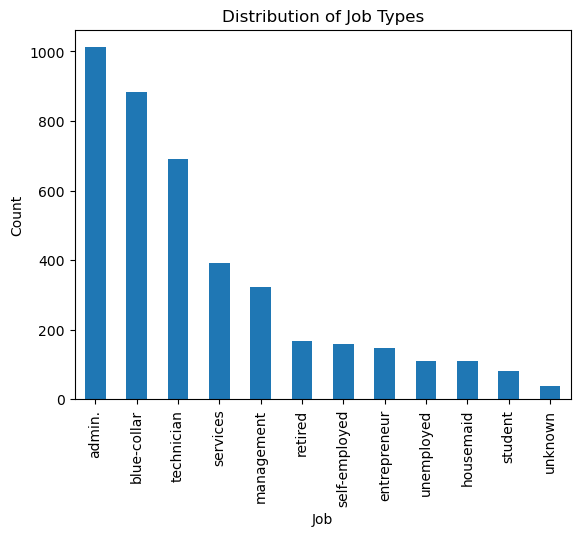

In [65]:
df["job"].value_counts().plot(kind="bar")
plt.title("Distribution of Job Types")
plt.xlabel("Job")
plt.ylabel("Count")
plt.show()

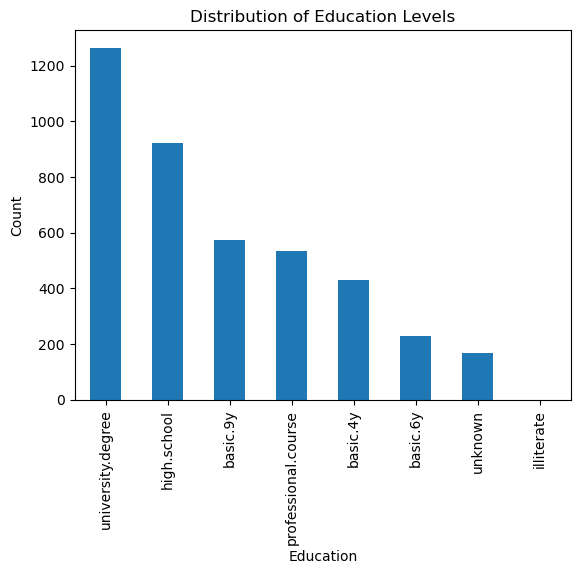

In [66]:
df["education"].value_counts().plot(kind="bar")
plt.title("Distribution of Education Levels")
plt.xlabel("Education")
plt.ylabel("Count")
plt.show()

One variable that requires special consideration is **duration**, which represents the length of the phone call.

Although this variable is highly predictive of whether a client subscribes to a term deposit, it is only known after the call has finished. Because the prediction should be made at the time of contact, using this variable would introduce data leakage. Therefore, it should not be used as a predictor in the model.

Another variable that requires attention is **pdays**, which indicates the number of days since the client was last contacted. The value 999 represents that the client was not previously contacted, which acts as a sentinel value rather than a true numerical measurement. This will require careful handling during preprocessing.

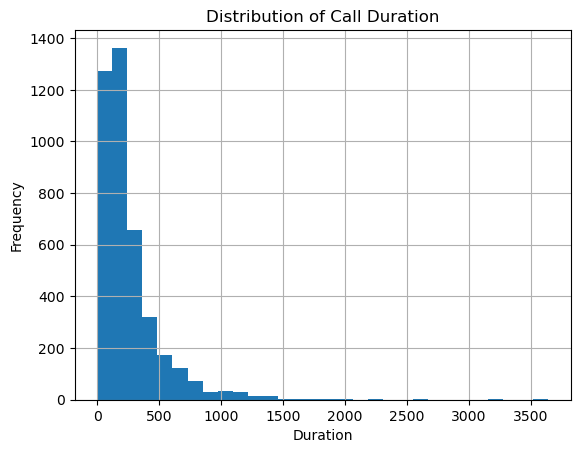

In [67]:
df["duration"].hist(bins=30)
plt.title("Distribution of Call Duration")
plt.xlabel("Duration")
plt.ylabel("Frequency")
plt.show()

## 3. Data Splitting

Before performing preprocessing steps such as imputation, encoding, scaling, or resampling, the dataset must be split into separate subsets for training, validation, and testing.

Splitting the data at this stage prevents **data leakage**, which would occur if preprocessing transformations were fitted using information from validation or test observations.

The dataset is split into three parts:

- **Training set**: used to fit preprocessing transformations and train the model
- **Validation set**: used to evaluate model performance and guide model decisions
- **Test set**: used for final evaluation after the pipeline has been developed

To preserve the class distribution of the target variable, **stratified sampling** is used with respect to the target variable `y`.

In [68]:
X = df.drop(columns="y")
y = df["y"]

In [69]:
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    stratify=y,
    random_state=42
)

In [70]:
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=42
)

In [71]:
print("Training set size:", X_train.shape)
print("Validation set size:", X_val.shape)
print("Test set size:", X_test.shape)

Training set size: (2883, 20)
Validation set size: (618, 20)
Test set size: (618, 20)


In [72]:
print("Training target distribution:")
print(y_train.value_counts(normalize=True))

print("\nValidation target distribution:")
print(y_val.value_counts(normalize=True))

print("\nTest target distribution:")
print(y_test.value_counts(normalize=True))

Training target distribution:
y
no     0.890392
yes    0.109608
Name: proportion, dtype: float64

Validation target distribution:
y
no     0.889968
yes    0.110032
Name: proportion, dtype: float64

Test target distribution:
y
no     0.891586
yes    0.108414
Name: proportion, dtype: float64


Stratified splitting ensures that the proportion of clients who subscribed to a term deposit is approximately the same across the training, validation, and test sets.

This is important because the dataset exhibits class imbalance. Without stratification, one subset could contain a much higher or lower proportion of positive outcomes, which would lead to unreliable model evaluation.

If the dataset were split **after** preprocessing transformations such as scaling, encoding, or resampling, information from the validation or test sets could influence those transformations. This would lead to **data leakage**, producing overly optimistic model performance estimates. By splitting the dataset first, we ensure that all subsequent preprocessing steps are fitted using only the training data.

## 4. Managing Missing Values

Before applying machine learning models, it is necessary to identify and properly handle missing data. Missing values can appear either explicitly (for example as `NaN`) or implicitly through special codes such as `"unknown"` or sentinel numerical values.

Explicit missing values can be detected directly through the dataset, while implicit missing values require examining the meaning of categories and special numeric values.

All preprocessing decisions must be based only on the **training set** in order to avoid data leakage.

In [73]:
X_train.isna().sum()

age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
dtype: int64

The dataset does not contain explicit missing values represented as `NaN`. However, several categorical variables include the category `"unknown"`, which likely represents missing or unavailable information.

In [74]:
for col in categorical_cols:
    print(col)
    print(X_train[col].value_counts())
    print()

job
job
admin.           708
blue-collar      594
technician       489
services         282
management       232
retired          115
self-employed    115
entrepreneur     105
housemaid         89
unemployed        76
student           53
unknown           25
Name: count, dtype: int64

marital
marital
married     1738
single       815
divorced     323
unknown        7
Name: count, dtype: int64

education
education
university.degree      890
high.school            661
basic.9y               396
professional.course    376
basic.4y               292
basic.6y               155
unknown                112
illiterate               1
Name: count, dtype: int64

default
default
no         2305
unknown     577
yes           1
Name: count, dtype: int64

housing
housing
yes        1545
no         1273
unknown      65
Name: count, dtype: int64

loan
loan
no         2336
yes         482
unknown      65
Name: count, dtype: int64

contact
contact
cellular     1829
telephone    1054
Name: count, dtype: 

KeyError: 'y'

Several categorical variables contain the category `"unknown"`. This category likely represents cases where the information about the client was not recorded or available. These values can therefore be interpreted as **implicit missing values**.

Rather than removing these observations, `"unknown"` will be treated as a valid category because it may contain useful information about the client or the data collection process.

In [ ]:
X_train["pdays"].value_counts().head()

The variable `pdays` represents the number of days since the client was last contacted during a previous campaign. The value `999` indicates that the client was not previously contacted.

Therefore, `999` does not represent a real number of days but rather a special code indicating the absence of previous contact. This acts as a **sentinel value** rather than a genuine measurement.

During preprocessing, this value will require special treatment so that it does not distort the interpretation of the variable.

The strategy for handling missing values is therefore:

• Explicit missing values (`NaN`): none detected in this dataset.

• Implicit missing values (`"unknown"` categories): retained as valid categories, since they may carry predictive information.

• Sentinel value in `pdays` (`999`): treated as a special case representing no previous contact rather than a true numerical measurement.

All preprocessing transformations such as imputation will be fitted **only on the training set**, and then applied to the validation and test sets to prevent data leakage.

## 5. Encoding Categorical Variables

Machine learning models such as Logistic Regression require numerical input features. However, several variables in this dataset are categorical, meaning they represent qualitative categories rather than numeric quantities.

These categorical variables must therefore be encoded into numerical representations before the model can use them. The choice of encoding method depends on the nature of the categorical variable and the assumptions of the learning algorithm.

In [ ]:
categorical_cols = X_train.select_dtypes(include="object").columns.tolist()
numerical_cols = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()

print("Categorical:", categorical_cols)
print("Numerical:", numerical_cols)

The dataset contains several categorical variables, including job type, marital status, education level, housing loan status, contact method, and previous campaign outcomes.

These variables represent discrete categories rather than numerical values and therefore require encoding before being used by the machine learning model.

### Nominal vs Ordinal Variables

Categorical variables can be classified as either **nominal** or **ordinal**.

• **Nominal variables** represent categories without an intrinsic order. Examples include job type, marital status, and contact method.

• **Ordinal variables** represent categories that have a natural ordering. In this dataset, the variable `education` can be considered ordinal because education levels follow a progression from lower to higher levels of education.

For nominal variables, assigning arbitrary numerical labels could introduce artificial relationships between categories. Therefore, one-hot encoding is preferred.

### Encoding Strategy

For this dataset, **one-hot encoding** is used for categorical variables. One-hot encoding creates a binary indicator variable for each category, allowing the model to represent each category independently.

This approach is particularly appropriate for Logistic Regression because it allows the model to assign separate coefficients to each category without imposing an artificial ordering.

In [ ]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)

encoded_train = encoder.fit_transform(X_train[categorical_cols])

encoded_train.shape

One-hot encoding increases the dimensionality of the dataset because each categorical variable is expanded into multiple binary features, one for each category.

For example, a variable with five possible categories will produce five binary columns after encoding. This increases the number of input features used by the model.

However, this representation allows Logistic Regression to learn separate coefficients for each category, improving interpretability and flexibility of the model.

The encoder is fitted **only on the training data**. This ensures that information from the validation or test sets does not influence the encoding process. If the encoder were fitted using the entire dataset, it could introduce data leakage by incorporating information about categories that appear only in the validation or test sets.

## 6. Feature Scaling

Feature scaling ensures that numerical variables are on a comparable scale. This is particularly important for models such as Logistic Regression, which are trained using gradient-based optimization methods.

If numerical variables have very different ranges, variables with larger magnitudes may dominate the optimization process and influence the learned model disproportionately.

Scaling numerical features improves numerical stability and ensures that regularization penalties affect all features more uniformly.

In [ ]:
numerical_cols = X_train.select_dtypes(include=["int64", "float64"]).columns

print("Numerical variables:")
print(numerical_cols)

The dataset contains several numerical variables, including demographic variables such as age, campaign-related variables such as campaign and pdays, and macroeconomic indicators such as euribor3m and cons.price.idx.

These variables have very different numerical ranges and therefore require scaling before being used by the model.

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train[numerical_cols])

Standardization transforms each numerical feature so that it has a mean of zero and a standard deviation of one.

This transformation is computed using statistics from the **training set only**, and the same transformation is later applied to the validation and test sets.

By scaling features in this way, the optimization algorithm used by Logistic Regression converges more efficiently and the learned coefficients become more comparable across variables.

Feature scaling affects Logistic Regression in several ways:

• **Gradient-based optimization:** When features have very different scales, gradient descent may converge slowly or become unstable.

• **Coefficient comparability:** Without scaling, the magnitude of coefficients depends on the units of the features rather than their relative importance.

• **Regularization penalties:** Regularization terms such as L2 penalties operate on the magnitude of coefficients. If features are not scaled, the regularization effect may disproportionately penalize some variables.

The scaler is fitted only on the training set to prevent data leakage. If scaling parameters were computed using the full dataset, information from the validation and test sets could influence the preprocessing stage, leading to overly optimistic evaluation results.

## 7. Feature Selection

Feature selection aims to remove features that provide little useful information for the model or that may introduce instability in the estimation process.

Removing unnecessary or redundant variables can improve model interpretability and reduce noise in the learning process. Feature selection should be performed carefully to avoid removing variables that may contain useful predictive information.

All feature selection decisions are based **only on the training set** to prevent data leakage.

In [75]:
from sklearn.feature_selection import VarianceThreshold

selector = VarianceThreshold(threshold=0.0)

selector.fit(X_train[numerical_cols])

,threshold,0.0


In [76]:
X_train[numerical_cols].var()

age                 107.446945
duration          67961.688316
campaign              6.868147
pdays             39049.991305
previous              0.314198
emp.var.rate          2.446584
cons.price.idx        0.342768
cons.conf.idx        21.430475
euribor3m             3.014293
nr.employed        5481.697956
dtype: float64

Features with extremely low variance provide little information for distinguishing between observations because their values remain almost constant across the dataset.

In this dataset, no numerical variables exhibit zero variance, so no features are removed based solely on variance.

In [77]:
corr_matrix = X_train[numerical_cols].corr()

corr_matrix

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
age,1.000000,0.037043,-0.013724,-0.047688,0.040628,-0.017167,0.002207,0.114373,-0.007678,-0.036400
duration,0.037043,1.000000,-0.085488,-0.041164,0.027580,-0.036311,0.016619,-0.039900,-0.040511,-0.053493
campaign,-0.013724,-0.085488,1.000000,0.068110,-0.098123,0.187127,0.149502,0.013836,0.169898,0.169503
pdays,-0.047688,-0.041164,0.068110,1.000000,-0.607106,0.282890,0.060471,-0.111135,0.316205,0.402703
previous,0.040628,0.027580,-0.098123,-0.607106,1.000000,-0.422470,-0.173426,-0.030424,-0.466142,-0.519873
emp.var.rate,-0.017167,-0.036311,0.187127,0.282890,-0.422470,1.000000,0.756447,0.171337,0.969648,0.895815
cons.price.idx,0.002207,0.016619,0.149502,0.060471,-0.173426,0.756447,1.000000,0.025311,0.654637,0.469817
cons.conf.idx,0.114373,-0.039900,0.013836,-0.111135,-0.030424,0.171337,0.025311,1.000000,0.256168,0.087675
euribor3m,-0.007678,-0.040511,0.169898,0.316205,-0.466142,0.969648,0.654637,0.256168,1.000000,0.942087
nr.employed,-0.036400,-0.053493,0.169503,0.402703,-0.519873,0.895815,0.469817,0.087675,0.942087,1.000000


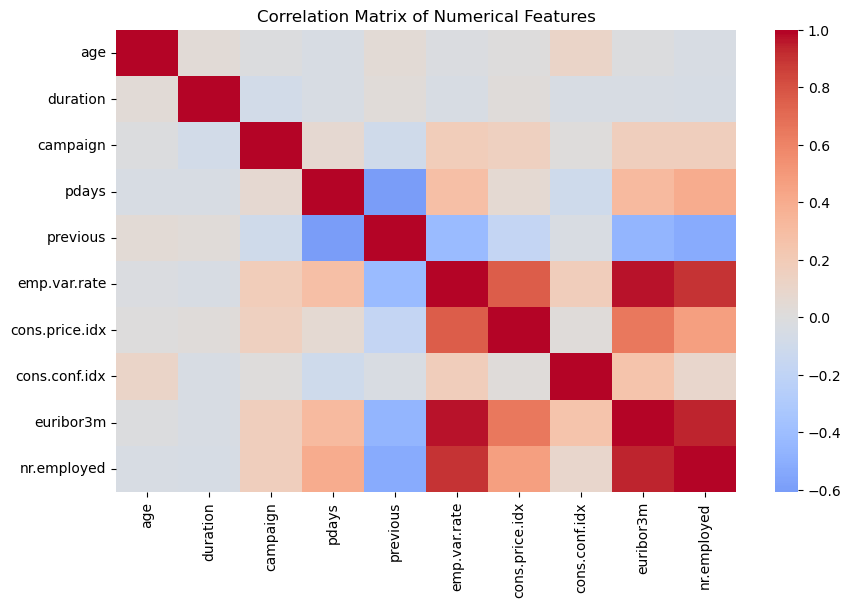

In [78]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.heatmap(corr_matrix, cmap="coolwarm", center=0)
plt.title("Correlation Matrix of Numerical Features")
plt.show()

### Interpretation of Correlations Between Numerical Features

The correlation matrix shows the pairwise relationships between numerical variables in the dataset.

Several macroeconomic variables appear to be strongly correlated. In particular, `emp.var.rate`, `euribor3m`, and `nr.employed` show very high positive correlations with each other. This is expected because these variables all reflect related economic conditions.

Strong correlations between predictors may lead to **multicollinearity**, which can make the coefficients of Logistic Regression unstable and harder to interpret. When multiple features contain very similar information, the model may have difficulty determining which feature is responsible for the observed effect.

A common approach is to remove one of the highly correlated variables if the correlation exceeds a threshold such as **0.85**. However, because these macroeconomic indicators may capture different aspects of the economic environment, all variables will be retained at this stage and their effects will later be assessed through the model coefficients.

### Conceptual Feature Removal

Some features may be problematic not because of statistical properties but because of their meaning within the prediction task.

The variable `duration` represents the length of the phone call with the client. Although it is highly predictive of whether the client subscribes to a term deposit, it is only known after the call has finished.

Because the prediction task assumes that the model must make predictions at the time of contact, including `duration` would introduce **data leakage**. Therefore, this variable should not be used as a predictor in the model.

In [79]:
X_train = X_train.drop(columns=["duration"])
X_val = X_val.drop(columns=["duration"])
X_test = X_test.drop(columns=["duration"])

Feature selection must be performed using only the training data. If feature selection were performed using the entire dataset before splitting, information from the validation and test sets could influence which features are retained.

This would introduce data leakage and lead to overly optimistic model performance estimates. By basing feature selection decisions only on the training set, we ensure that the evaluation process remains unbiased.

## 8. Addressing Class Imbalance

Class imbalance occurs when one class in the target variable appears much more frequently than the other. In this dataset, most clients did not subscribe to the term deposit, while a much smaller proportion did.

Class imbalance can affect the performance of machine learning models because the model may become biased toward predicting the majority class. This can lead to misleading evaluation metrics such as high accuracy but poor detection of the minority class.

In [80]:
y_train.value_counts()

y
no     2567
yes     316
Name: count, dtype: int64

In [81]:
y_train.value_counts(normalize=True)

y
no     0.890392
yes    0.109608
Name: proportion, dtype: float64

The distribution of the target variable shows a strong imbalance between the classes. The majority of observations correspond to clients who did not subscribe to a term deposit, while a much smaller proportion corresponds to clients who did subscribe.

If this imbalance is not addressed, a model could achieve high accuracy simply by predicting the majority class for most observations.

For example, if 90% of clients do not subscribe to a term deposit, a naive classifier that always predicts "no" would achieve 90% accuracy. However, such a model would fail to identify clients who are likely to subscribe, which is the primary objective of the marketing campaign.